# Notebook 01 — Episode Ground Truth

**Study:** Detecting the START and END of retail euphoria episodes from the
crowd alone (RetailRadar, July 2026).
**This notebook:** builds the price-defined ground truth every later result
is scored against — the **episode catalog** — before any feature or model is
looked at. Labels first, models later; the order is the point.

## The research question

> Can crowd-only features (mentions + scored sentiment; **price is never an
> input**) detect both the START and the END of extreme retail euphoria
> episodes — GME-scale rallies only — sparingly, with hit rate maximised
> across all judgeable periods?

## What counts as an episode (all price-based, all testing-only)

An **episode** is the full boom→bust arc around a *confirmed top*. The top
definition is inherited unchanged from the validated euphoria detector
(`analytics/euphoria.py`, rules G1–G3):

* **G1 local max** — the highest close in a ±21d window;
* **G2 boom** — the peak sits ≥ **25%** (ETF/theme) / **50%** (single name)
  above the minimum close of the preceding 120d;
* **G3 bust** — a drawdown of ≥ **15%** / **30%** within the next 90d.

This notebook extends each confirmed peak into an arc using only quantities
G2/G3 already measure:

* **trough** = the argmin of the same 120d prior window G2 measures the boom
  from (no new lookback is introduced);
* **bust date** = the first day G3's drawdown condition is met.

## Desk decisions recorded BEFORE any result (the "no arbitrary numbers" register)

| Quantity | Value | Where it comes from |
|---|---|---|
| Onset hit window | `[trough, trough+45d]`, **capped at the peak** | 45d mirrors the existing false-alarm horizon in `score_alerts` (an alert is false if no peak follows within 45d) — no new constant. The cap exists because, for fast rallies, an uncapped window would let an alert fired *after* the top count as "caught the start". Desk decision, July 2026. |
| LATE ≠ FALSE | alerts in `(onset end, peak]` reported separately | Calling a mid-rally alert a *hit* inflates the onset claim; calling it *false* punishes an alert inside a genuine episode. Both distortions are avoided by a third bucket. |
| Boom/bust thresholds | 25/50%, 15/30% | Inherited, unchanged, from the validated top study (dual thresholds are a documented desk decision there). |
| Top hit window | `[peak−30d, peak+1d]` | The stated aim of the existing detector — unchanged. |

**Methodological caveat stated up front:** because the trough is defined
inside G2's 120d lookback, `run_days ≤ 120` *by construction*. The trough is
"the measured low of the final run-up", not "the day the rally was born".
This is consistent with how booms are already defined in the validated
study; it is stated here so the run-length distribution below is read
correctly.

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# House chart rules (identical to helper/research_charts.py): one axis per
# panel, fixed validated categorical palette, direct labels, recessive grid.
C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
RESEARCH_DIR.mkdir(parents=True, exist_ok=True)

## Build the universe and the catalog

The instrument universe is exactly the euphoria detector's: 34 theme anchor
ETFs (rates/bonds and real estate excluded by desk decision) plus the top-25
data-chosen single names (≥3,000 scored posts, priced). The catalog builder
lives in `analytics/euphoria_phases.py` — **the same module the production
pipeline will import**, so the research and the dashboard can never drift.

In [2]:
from analytics.euphoria import build_all_series
from analytics.euphoria_phases import episode_catalog, ONSET_WINDOW_DAYS

t0 = time.time()
prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
catalog = episode_catalog(series, pxmap)
print(f"built in {time.time()-t0:.1f}s | universe: {len(series)} instruments "
      f"({sum(1 for s in series if s.kind=='theme')} themes, "
      f"{sum(1 for s in series if s.kind=='single')} single names)")
print(f"episodes: {len(catalog)} | onset-detectable: "
      f"{int(catalog.onset_detectable.sum())} | top-detectable: "
      f"{int(catalog.top_detectable.sum())}")

built in 22.7s | universe: 59 instruments (34 themes, 25 single names)
episodes: 333 | onset-detectable: 126 | top-detectable: 136


## Episodes per year — with BOTH denominators, always

`onset/top-detectable` = the coverage gate (≥100 scored posts in 28d, the
existing A0 rule) held on at least one day of the respective window. A top
that happened while the archive was thin stays in the **all** column — the
detector is *blind* there, not *wrong* — but no crowd detector can honestly
be scored on it. 2024–25 are the known coverage desert.

In [3]:
per_year = (catalog.groupby("year")
            .agg(episodes=("name", "count"),
                 onset_detectable=("onset_detectable", "sum"),
                 top_detectable=("top_detectable", "sum"),
                 themes=("kind", lambda k: int((k == "theme").sum())),
                 singles=("kind", lambda k: int((k == "single").sum()))))
per_year

,episodes,onset_detectable,top_detectable,themes,singles
year,,,,,
2017,8,1,1,3,5
2018,10,5,5,5,5
2019,21,8,8,8,13
2020,50,24,24,21,29
2021,62,52,58,24,38
2022,47,24,22,20,27
2023,35,7,5,13,22
2024,44,0,0,26,18
2025,34,0,0,10,24


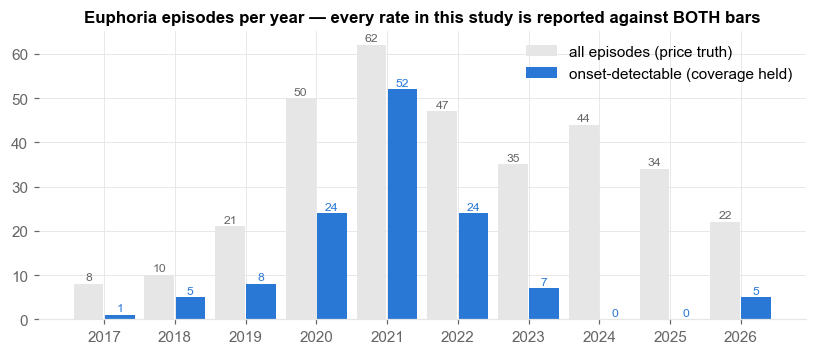

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(len(per_year))
ax.bar(x - 0.22, per_year["episodes"], 0.42, color=GRID,
       label="all episodes (price truth)")
ax.bar(x + 0.22, per_year["onset_detectable"], 0.42, color=C1,
       label="onset-detectable (coverage held)")
for i, (a, b) in enumerate(zip(per_year["episodes"],
                               per_year["onset_detectable"])):
    ax.text(i - 0.22, a + 0.8, str(a), ha="center", fontsize=8, color=MUTED)
    ax.text(i + 0.22, b + 0.8, str(b), ha="center", fontsize=8, color=C1)
ax.set_xticks(x, per_year.index)
ax.set_title("Euphoria episodes per year — every rate in this study is "
             "reported against BOTH bars")
ax.legend(frameon=False, loc="upper right")
despine(ax)
plt.show()

## What the episodes look like (and why 45d is a reasonable window length)

Three distributions matter for everything downstream:

1. **Boom size** — how big the rallies we are trying to catch are (log
   scale; GME 2021 is a +3,700% outlier).
2. **Bust size** — what "the party ends" costs (this is why calling tops is
   worth doing at all).
3. **Run length** (trough→peak) — the median run is ~86 days, so a 45d onset
   window covers roughly the first half of a typical run-up. Remember the
   caveat above: this distribution is right-truncated at 120 by the
   definition of the trough.

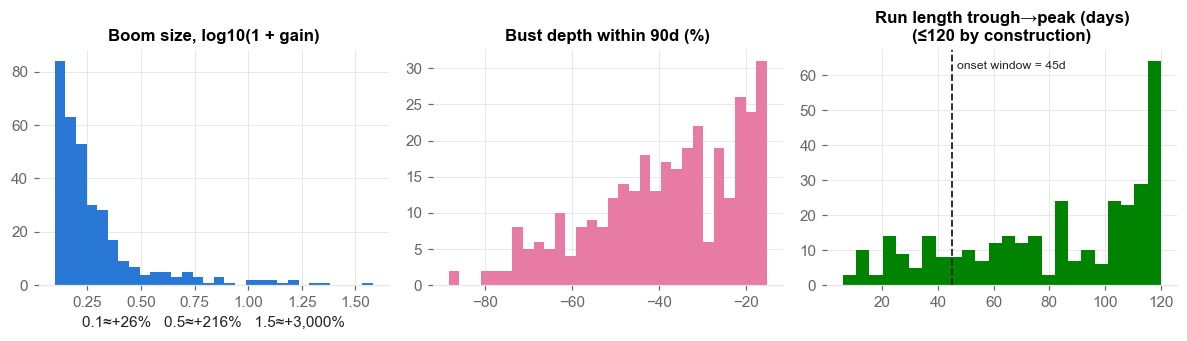

median run 86d -> the 45d onset window covers the first 52% of a median run-up


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].hist(np.log10(1 + catalog.boom_pct), bins=30, color=C1)
axes[0].set_title("Boom size, log10(1 + gain)")
axes[0].set_xlabel("0.1≈+26%   0.5≈+216%   1.5≈+3,000%")
axes[1].hist(100 * catalog.bust_pct, bins=30, color=C3)
axes[1].set_title("Bust depth within 90d (%)")
axes[2].hist(catalog.run_days, bins=24, color=C2)
axes[2].axvline(ONSET_WINDOW_DAYS, color=INK, lw=1.2, ls="--")
axes[2].text(ONSET_WINDOW_DAYS + 2, axes[2].get_ylim()[1] * 0.92,
             f"onset window = {ONSET_WINDOW_DAYS}d", fontsize=8, color=INK)
axes[2].set_title("Run length trough→peak (days)\n(≤120 by construction)")
for ax in axes:
    despine(ax)
fig.tight_layout()
plt.show()

med = catalog.run_days.median()
print(f"median run {med:.0f}d -> the 45d onset window covers the first "
      f"{100*ONSET_WINDOW_DAYS/med:.0f}% of a median run-up")

## Case studies — the episodes this project exists for

Shaded: **blue = onset window** `[trough, min(trough+45d, peak)]`,
**pink = peak→bust**. Log price panels where the boom demands it. These are
the pictures every later notebook's alerts will be drawn onto.

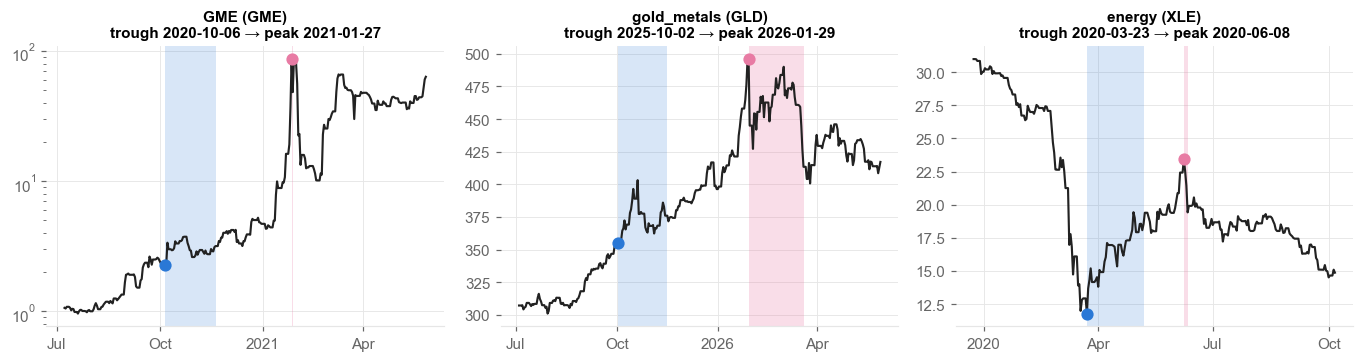

third panel (data-chosen): energy 2020-06-08, boom +99%, bust -27%


In [6]:
import matplotlib.dates as mdates

def case_panel(ax, name, symbol, trough, peak, onset_hi, bust, log=False):
    px = pxmap[symbol].dropna()
    lo = trough - pd.Timedelta(days=90)
    hi = peak + pd.Timedelta(days=120)
    win = px.loc[lo:hi]
    ax.plot(win.index, win.values, color=INK, lw=1.4)
    ax.axvspan(trough, onset_hi, color=C1, alpha=0.18, lw=0)
    if bust is not None and not pd.isna(bust):
        ax.axvspan(peak, bust, color=C3, alpha=0.25, lw=0)
    ax.plot([trough], [px.loc[trough]], "o", color=C1, ms=7)
    ax.plot([peak], [px.loc[peak]], "o", color=C3, ms=7)
    if log:
        ax.set_yscale("log")
    ax.set_title(f"{name} ({symbol})\ntrough {trough.date()} → "
                 f"peak {peak.date()}", fontsize=10)
    loc = mdates.AutoDateLocator(minticks=3, maxticks=5)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    despine(ax)

# GME 2021 + gold 2026 are named in the project aim; the third panel is the
# largest onset-detectable THEME boom, chosen by the data, not by hand.
gme = catalog[(catalog.name == "GME") & (catalog.year == 2021)].iloc[0]
gld = catalog[(catalog.name == "gold_metals") & (catalog.year == 2026)].iloc[0]
theme_pool = catalog[(catalog.kind == "theme") & catalog.onset_detectable
                     & ~catalog.name.isin(["gold_metals"])]
third = theme_pool.sort_values("boom_pct", ascending=False).iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
case_panel(axes[0], "GME", "GME", gme.trough, gme.peak, gme.onset_hi,
           gme.bust_date, log=True)
case_panel(axes[1], "gold_metals", "GLD", gld.trough, gld.peak, gld.onset_hi,
           gld.bust_date)
case_panel(axes[2], third["name"], third.symbol, third.trough, third.peak,
           third.onset_hi, third.bust_date)
fig.tight_layout()
plt.show()
print(f"third panel (data-chosen): {third['name']} {third.peak.date()}, "
      f"boom +{100*third.boom_pct:.0f}%, bust {100*third.bust_pct:.0f}%")

## Save the catalog — the single source of truth for notebooks 02–04

In [7]:
out_path = ROOT / "data" / "processed" / "episodes.parquet"
catalog.to_parquet(out_path, index=False)

stats = {
    "episodes_total": int(len(catalog)),
    "onset_detectable": int(catalog.onset_detectable.sum()),
    "top_detectable": int(catalog.top_detectable.sum()),
    "median_run_days": float(catalog.run_days.median()),
    "median_boom_pct": float(catalog.boom_pct.median()),
    "median_bust_pct": float(catalog.bust_pct.median()),
    "onset_window_days": int(ONSET_WINDOW_DAYS),
    "per_year": {str(y): {"episodes": int(r.episodes),
                          "onset_detectable": int(r.onset_detectable),
                          "top_detectable": int(r.top_detectable)}
                 for y, r in per_year.iterrows()},
}
with open(RESEARCH_DIR / "nb01_episode_stats.json", "w") as f:
    json.dump(stats, f, indent=1)
print(f"saved {out_path.name} ({len(catalog)} episodes) + nb01_episode_stats.json")

saved episodes.parquet (333 episodes) + nb01_episode_stats.json


## Limitations carried forward (pre-answered, not hidden)

1. **Coverage deserts.** 2024–25 have zero detectable episodes (thin
   archive coverage). Every downstream rate is reported against both the
   all-episodes and the detectable denominators; the detector is *blind*
   there, not *validated* there.
2. **Trough truncation.** `run_days ≤ 120` by construction (trough lives
   inside G2's 120d lookback). "Onset" therefore means "the start of the
   final measured run-up", which for slow multi-quarter rallies is later
   than the narrative start.
3. **Price-defined truth.** An episode requires a *confirmed* bust; euphoria
   that deflated slowly (no ≥15/30% drawdown inside 90d) never enters the
   catalog. The detectors are scored only on the arcs a desk would actually
   have wanted flagged.
4. **Overlapping episodes.** Consecutive peaks closer than 30d are collapsed
   upstream (euphoria.py); distinct peaks 30–120d apart can still produce
   overlapping arcs (visible in GME 2021). Labels treat each arc
   independently; the alert cooldown (21d) is what prevents double-alerting
   in practice.
5. **V-recoveries qualify.** A "boom off a 120d low" admits crash-rebound
   rallies (the data-chosen third case study is energy's post-COVID
   V-recovery). The catalog's semantics are "extreme rally that then broke",
   which is broader than "mania". This is a property of the validated G2
   rule, inherited knowingly — the crowd features must EARN the distinction
   between recovery and mania in the tournament, not have it assumed.

**Next (Notebook 02):** the six-feature onset bank vs the incumbent E1–E5,
put through the thesis-style importance battery — per-feature AUROC/AP,
leave-one-out ablation, perturbation robustness, and the correlation
matrix — against these labels.